## PART 1 - Data wrangling and data understanding
You have to download (from Canvas) the following files:

a) DATOS_VENTAS.xlsx: historical monthly data for all products sold for the last 3-4 years
You have to:

a) Do a correct data wrangling/cleanning to prepare the data for descriptive statistics and modelling:
- You have to check for null values, possible duplicate records (1 same product with 2 product ID, or 1 product ID with 2 different product names),
- Then you have to do the right data collapsing, possible reshaping, and variable transformations, and come up with the right data structure for analysis. Remember dataset structure types (long-format, wide-format).

b) Do the corresponding data analysis to respond to the objective 1)

c) Run and interpret the regression model for your fab

### The objectives of your analysis are the following:

1. Provide understanding of the milk category by manufacturer (fab) in terms of 
a) market share composition by year, and b) sales and price performance over time. Identify the top fabs that make 80% of the market share for the last 12 months. Show relevant descriptive statistics according to your analysis and assumptions.

2. Provide initial correlation analysis to understand important relationship within the data. You have to justify how and why you did this correlation analysis. Explain your results

For 1) and 2) Present your analysis in tables and selected graphs to provide a good understanding of the data.

## PART 2 - Data modelling
### You have to design, run models to respond all the objectives and questions

3. Design and run regression model(s) to estimate price sensitivity (direct price elasticity) for the top product of your manufacturer (fab#). Identify the top product as the product that sold the most for the last 12 months. For this model, only consider the price change as explanatory variable (do not include other factors such as seasonality or tren).

You have to present the regression output for the model and provide a clear interpretation for the regression output: parameter estimates (beta coefficients), t-Statistics, pvalues, 95% confidence intervals, and R-square.

4. Propose how you could improve your model design to incorporate the following factors: cross-price elasticity with other products, seasonality and growth trend. Here you have to explain your model design, not run the model.

5. For your model (of the top product), add variables to include the effects of seasonality and growing volume trend. Interpret the model with your own words.

Run the model, show the regression output and interpret the outputs

In addition, respond to the following questions:

Did the estimates of direct price elasticity change compared with the previous model? What happened with the statistical significance of the price elasticity? Why do you think the estimates change, and which estimate is the best? Explain clearly with your own words.

6. Propose how you could forecast price and sales of the top product for the next 24 months. Which types of models you can use to do this. You have to do your own research. Consider not only regression models, but any type of machine learning/ AI models.


In [1]:
import pandas as pd

file_path = '/Users/emiliolopez/Desktop/Septimo Semestre/Dorantes/Data Ventas - Gpo 601.xlsx'
df = pd.read_excel(file_path)
df.head()

,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
0,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,14,4,2022-04-04,2022-04-01,17492.00,876,19.968037,73,239.616438,12
1,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,15,4,2022-04-11,2022-04-01,53364.90,2676,19.942040,223,239.304484,12
2,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,16,4,2022-04-18,2022-04-01,75747.96,3828,19.787868,319,237.454420,12
3,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,17,4,2022-04-25,2022-04-01,73193.36,3684,19.867904,307,238.414853,12
4,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,18,5,2022-05-02,2022-05-01,94031.14,4644,20.247877,387,242.974522,12


In [2]:
# Buscamos si hay valores nulos y los eliminamos
display(df.isnull().sum())
df = df.dropna(subset=['PRECIO_UNITARIO_LITRO'])
display(df.isnull().sum())

CORTE                      0
FABRICANTE                 0
ID                         0
PRODUCTO                   0
AÑO1                       0
SEMANA                     0
MES                        0
FECHAW                     0
FECHAM                     0
VENTA_VALOR                0
LITROS                     0
PRECIO_UNITARIO_LITRO      3
PAQUETES                   0
PRECIO_UNITARIO_PAQUETE    3
UNIDADES_EN_PAQUETE        0
dtype: int64

CORTE                      0
FABRICANTE                 0
ID                         0
PRODUCTO                   0
AÑO1                       0
SEMANA                     0
MES                        0
FECHAW                     0
FECHAM                     0
VENTA_VALOR                0
LITROS                     0
PRECIO_UNITARIO_LITRO      0
PAQUETES                   0
PRECIO_UNITARIO_PAQUETE    0
UNIDADES_EN_PAQUETE        0
dtype: int64

In [3]:
#Revisamos si hay filas duplicadas
dup_full = df.duplicated()
print(f"Filas totalmente duplicadas: {dup_full.sum()}")

# Ahora buscamos a un mismo producto con dos identificadores de producto
id_to_producto = df.groupby('ID')['PRODUCTO'].nunique()

# O a un identificador de producto con dos nombres de producto diferentes
producto_to_id = df.groupby('PRODUCTO')['ID'].nunique()

ids_inconsistentes = id_to_producto[id_to_producto > 1]
productos_inconsistentes = producto_to_id[producto_to_id > 1]

print(f"IDs con más de un PRODUCTO distinto: {len(ids_inconsistentes)}")
print(f"PRODUCTOS con más de un ID distinto: {len(productos_inconsistentes)}")

Filas totalmente duplicadas: 0
IDs con más de un PRODUCTO distinto: 0
PRODUCTOS con más de un ID distinto: 0


In [4]:
# Ahora buscamos a un mismo producto repetido en la misma semana
conteo_semanal = df.groupby(['FABRICANTE', 'PRODUCTO', 'FECHAW']).size()
n_dup_semanal = (conteo_semanal > 1).sum()

print(f"Productos duplicados por semana: {n_dup_semanal}")

Productos duplicados por semana: 276


In [5]:
#Ahora vamos a agrupar las filas repetidas por semana para dejar solo una entrada.
# Guardamos los totales antes de colapsar para comprobar que no se pierde ni se genera venta
total_venta_antes = df['VENTA_VALOR'].sum()
total_litros_antes = df['LITROS'].sum()

columnas_llave = ['CORTE', 'FABRICANTE', 'ID', 'PRODUCTO', 'AÑO1', 'SEMANA', 'MES', 'FECHAW', 'FECHAM']

df = df.groupby(columnas_llave, as_index=False).agg(
    VENTA_VALOR=('VENTA_VALOR', 'sum'),
    LITROS=('LITROS', 'sum'),
    PAQUETES=('PAQUETES', 'sum'),
    UNIDADES_EN_PAQUETE=('UNIDADES_EN_PAQUETE', 'first'),
)

df['PRECIO_UNITARIO_LITRO'] = df['VENTA_VALOR'] / df['LITROS']
df['PRECIO_UNITARIO_PAQUETE'] = df['VENTA_VALOR'] / df['PAQUETES']

dup_restantes = (df.groupby(['FABRICANTE', 'PRODUCTO', 'FECHAW']).size() > 1).sum()
print(f"Productos duplicados por semana: {dup_restantes}")

# Comprobamos que no se perdió ni se generó venta al colapsar los duplicados
print(f"Venta total antes: {total_venta_antes:.2f} | después: {df['VENTA_VALOR'].sum():.2f}")
print(f"Litros totales antes: {total_litros_antes} | después: {df['LITROS'].sum()}")

Productos duplicados por semana: 0
Venta total antes: 2292961809.85 | después: 2292961809.85
Litros totales antes: 113540892 | después: 113540892


In [6]:
#Buscamos valores negativos y los tomamos como valores que no son validos.
columnas_numericas = ['VENTA_VALOR', 'LITROS', 'PAQUETES',
                      'PRECIO_UNITARIO_LITRO', 'PRECIO_UNITARIO_PAQUETE', 'UNIDADES_EN_PAQUETE']

for col in columnas_numericas:
    print(f"{col}: {(df[col] < 0).sum()} filas negativas")

filas_negativas = df[(df[columnas_numericas] < 0).any(axis=1)]
print(f"\nTotal filas con algún valor negativo: {len(filas_negativas)}")
display(filas_negativas)


VENTA_VALOR: 2 filas negativas
LITROS: 2 filas negativas
PAQUETES: 2 filas negativas
PRECIO_UNITARIO_LITRO: 0 filas negativas
PRECIO_UNITARIO_PAQUETE: 0 filas negativas
UNIDADES_EN_PAQUETE: 0 filas negativas

Total filas con algún valor negativo: 2


,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PAQUETES,UNIDADES_EN_PAQUETE,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE
1304,TN,FAB1,Leche Clasica Semi 1 L,FAB1_Leche Clasica Semi 1 L,2023,36,9,2023-09-04,2023-09-01,-3378.01,-156,-13,12,21.65391,259.846923
3015,TN,FAB6,12/1L Leche Y Pan En Tera,FAB6_12/1L Leche Y Pan En Tera,2023,48,11,2023-11-27,2023-11-01,-1020.00,-60,-5,12,17.00000,204.000000


In [7]:
print(f"Filas antes de quitar negativos: {len(df)}")
df = df[~(df[columnas_numericas] < 0).any(axis=1)]
print(f"Filas después de quitar negativos: {len(df)}")

Filas antes de quitar negativos: 3017
Filas después de quitar negativos: 3015


In [8]:
#Se crea un df para agrupar la produccion de cada fabricante por mes
monthly_fab = (
    df.groupby(['FABRICANTE', 'AÑO1', 'MES', 'FECHAM'], as_index=False)
      .agg(VENTA_VALOR=('VENTA_VALOR', 'sum'),
           LITROS=('LITROS', 'sum'))
)

monthly_fab['PRECIO_PROMEDIO_LITRO'] = monthly_fab['VENTA_VALOR'] / monthly_fab['LITROS']

monthly_fab['MARKET_SHARE_VALOR'] = (
    monthly_fab['VENTA_VALOR'] / monthly_fab.groupby('FECHAM')['VENTA_VALOR'].transform('sum')
)

monthly_fab.sort_values(['FECHAM', 'MARKET_SHARE_VALOR'], ascending=[True, False]).head(10)

,FABRICANTE,AÑO1,MES,FECHAM,VENTA_VALOR,LITROS,PRECIO_PROMEDIO_LITRO,MARKET_SHARE_VALOR
0,FAB1,2022,1,2022-01-01,14909215.92,795828,18.734219,0.452662
86,FAB3,2022,1,2022-01-01,11836538.78,645600,18.334168,0.359372
43,FAB2,2022,1,2022-01-01,4905007.17,285720,17.167182,0.148922
142,FAB6,2022,1,2022-01-01,1286001.63,90888,14.149301,0.039045
1,FAB1,2022,2,2022-02-01,30450108.81,1682580,18.097273,0.523003
87,FAB3,2022,2,2022-02-01,17270016.27,900240,19.183791,0.296625
44,FAB2,2022,2,2022-02-01,9003709.05,522216,17.241350,0.154645
143,FAB6,2022,2,2022-02-01,1497804.46,105732,14.166047,0.025726
2,FAB1,2022,3,2022-03-01,23306184.89,1236000,18.856137,0.402920
88,FAB3,2022,3,2022-03-01,19804506.19,1077396,18.381826,0.342382


In [9]:
#Se crea un df para agrupar la produccion de cada fabricante por año
yearly_fab = (
    df.groupby(['FABRICANTE', 'AÑO1'], as_index=False)
      .agg(VENTA_VALOR=('VENTA_VALOR', 'sum'),
           LITROS=('LITROS', 'sum'))
)

yearly_fab['PRECIO_PROMEDIO_LITRO'] = yearly_fab['VENTA_VALOR'] / yearly_fab['LITROS']

yearly_fab['MARKET_SHARE_VALOR'] = (
    yearly_fab['VENTA_VALOR'] / yearly_fab.groupby('AÑO1')['VENTA_VALOR'].transform('sum')
)

yearly_fab.sort_values(['AÑO1', 'MARKET_SHARE_VALOR'], ascending=[True, False])

,FABRICANTE,AÑO1,VENTA_VALOR,LITROS,PRECIO_PROMEDIO_LITRO,MARKET_SHARE_VALOR
0,FAB1,2022,2.634132e+08,13865772,18.997371,4.463671e-01
8,FAB3,2022,1.853947e+08,9600672,19.310597,3.141608e-01
4,FAB2,2022,1.240779e+08,7070040,17.549821,2.102564e-01
14,FAB6,2022,1.724103e+07,1140648,15.115118,2.921580e-02
1,FAB1,2023,2.835175e+08,14540592,19.498350,4.642984e-01
9,FAB3,2023,1.766527e+08,8685408,20.339018,2.892927e-01
5,FAB2,2023,1.382942e+08,7482156,18.483198,2.264755e-01
15,FAB6,2023,1.217204e+07,752640,16.172462,1.993337e-02
2,FAB1,2024,2.745553e+08,12758208,21.519892,4.138764e-01
10,FAB3,2024,2.092758e+08,9429228,22.194374,3.154713e-01


In [10]:
#Se crea un df para tener a los top fabricantes que tengan el 80% del mercado en los ultimos 12 meses
fecha_max = df['FECHAM'].max()
fecha_inicio = fecha_max - pd.DateOffset(months=11)
ultimos_12m = df[df['FECHAM'] >= fecha_inicio]

fab_last12 = (
    ultimos_12m.groupby('FABRICANTE', as_index=False)['VENTA_VALOR']
    .sum()
    .sort_values('VENTA_VALOR', ascending=False)
)
fab_last12['MARKET_SHARE'] = fab_last12['VENTA_VALOR'] / fab_last12['VENTA_VALOR'].sum()
fab_last12['SHARE_ACUMULADO'] = fab_last12['MARKET_SHARE'].cumsum()

# Fabricantes que, acumulados, forman el 80% del mercado
top_fabs_80 = fab_last12[fab_last12['SHARE_ACUMULADO'].shift(fill_value=0) < 0.80]
print(f"Ventana analizada: {fecha_inicio.date()} a {fecha_max.date()}")
print(f"Fabricantes que concentran el 80% del mercado: {len(top_fabs_80)} de {len(fab_last12)}")
top_fabs_80

Ventana analizada: 2024-08-01 a 2025-07-01
Fabricantes que concentran el 80% del mercado: 3 de 4


,FABRICANTE,VENTA_VALOR,MARKET_SHARE,SHARE_ACUMULADO
0,FAB1,2.553917e+08,0.359326,0.359326
2,FAB3,2.040994e+08,0.287160,0.646486
3,FAB5,1.563707e+08,0.220008,0.866494


### Qué se hizo en la limpieza y transformación de datos

Primero se cargó el dataset para posteriormente buscar datos nulos, los cuales se encontraron 3 y fueron eliminados. Después buscamos valores duplicados, se revisó que cada uno de los IDs estuviera asociado a un solo producto y viceversa, en este caso no encontramos ninguno. Después me percaté de que había varios productos duplicados, eran 276 productos con entradas dobles por semana, lo que se hizo fue juntar ambas entradas para solo dejar una con los datos de dicha semana y se verifico que no se hayan perdido ventas o litros despues de juntarlos. Luego buscamos valores negativos en los datos, los cuales encontramos 2 filas; las consideramos registros inválidos ya que no puede haber ventas negativas, al menos que sean devoluciones, pero en este caso no tenemos una columna dedicada por lo que los eliminamos. Posteriormente construimos 3 data frames, monthly_fab, yearly_fab y fab_last12, los cuales nos van a ayudar a responder el punto 1.

## 1. Provide understanding of the milk category by manufacturer (fab) in terms of
a) market share composition by year

b) sales and price performance over time. 

Identify the top fabs that make 80% of the market share for the last 12 months. Show relevant descriptive statistics according to your analysis and assumptions.

In [11]:
import matplotlib.pyplot as plt

# Se calcula la composicion del mercado en base a los fabricantes por año
yearly_share_wide = yearly_fab.pivot_table(index='AÑO1', columns='FABRICANTE', values='MARKET_SHARE_VALOR')
(yearly_share_wide * 100).round(1)

FABRICANTE,FAB1,FAB2,FAB3,FAB5,FAB6
AÑO1,,,,,
2022,44.6,21.0,31.4,NaN,2.9
2023,46.4,22.6,28.9,NaN,2.0
2024,41.4,20.7,31.5,6.3,0.0
2025,33.7,11.6,28.0,26.7,NaN


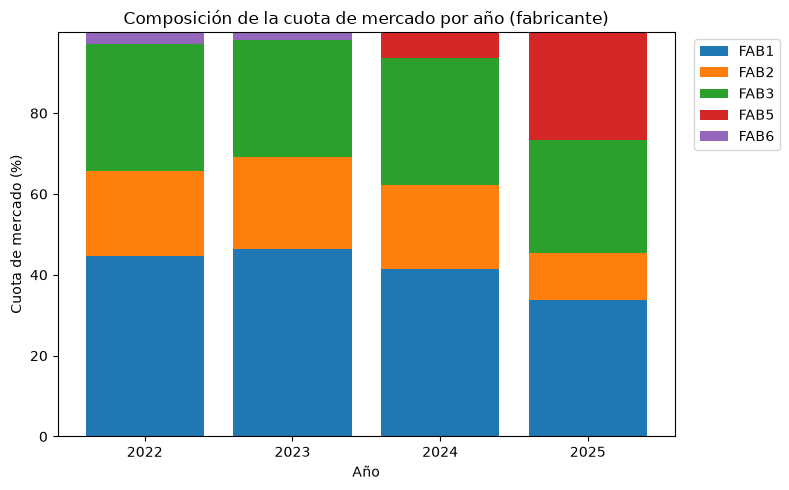

In [12]:
#Se utilizan los df previamente obtenidos para graficar
fig, ax = plt.subplots(figsize=(8, 5))
bottom = None
for fab in yearly_share_wide.columns:
    # fillna(0): un fabricante que no existía ese año aporta 0% al stack (si no, el NaN
    # se propaga al "bottom" acumulado y las barras de los fabricantes siguientes no se dibujan)
    valores = yearly_share_wide[fab].fillna(0) * 100
    ax.bar(yearly_share_wide.index.astype(str), valores, bottom=bottom, label=fab)
    bottom = valores if bottom is None else bottom + valores

ax.set_ylabel('Cuota de mercado (%)')
ax.set_xlabel('Año')
ax.set_title('Composición de la cuota de mercado por año (fabricante)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

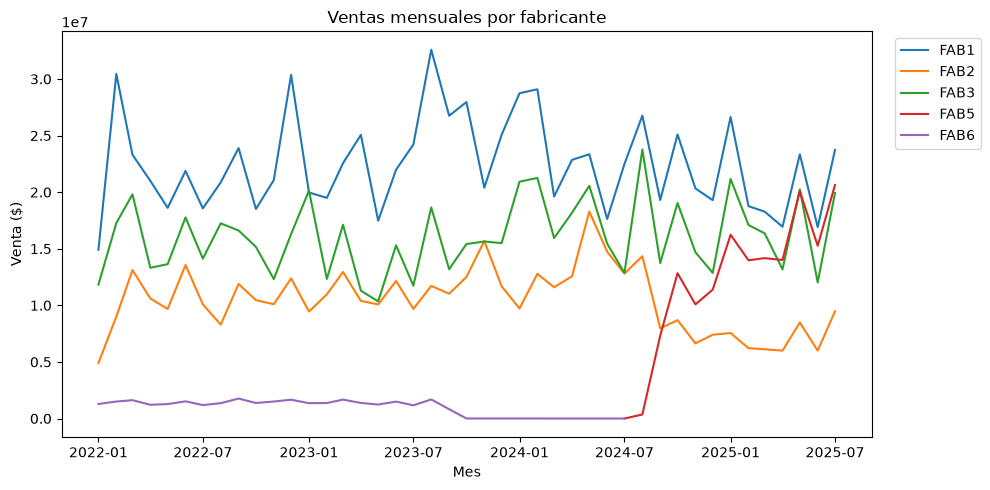

In [13]:
#Se utilizan los df previamente obtenidos para graficar
fig, ax = plt.subplots(figsize=(10, 5))
for fab, g in monthly_fab.groupby('FABRICANTE'):
    ax.plot(g['FECHAM'], g['VENTA_VALOR'], label=fab)

ax.set_title('Ventas mensuales por fabricante')
ax.set_xlabel('Mes')
ax.set_ylabel('Venta ($)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

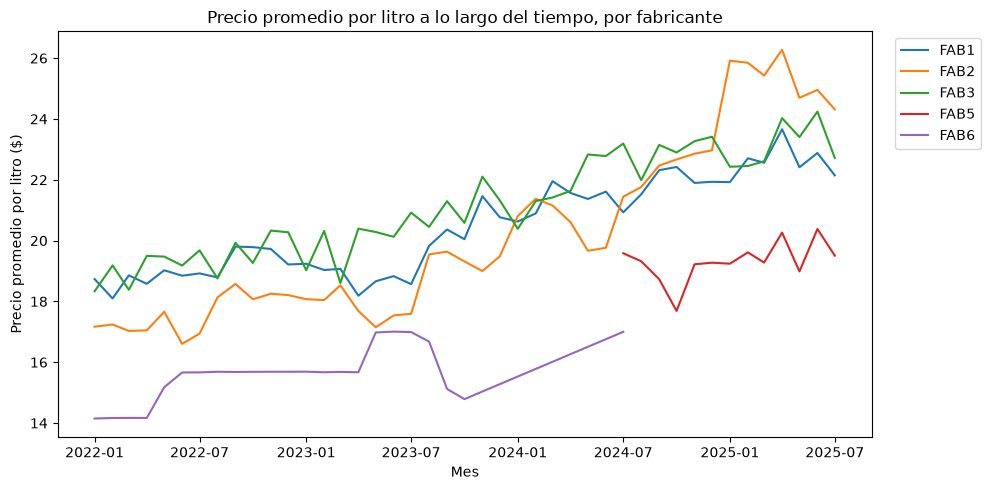

In [14]:
#Se utilizan los df previamente obtenidos para graficar
fig, ax = plt.subplots(figsize=(10, 5))
for fab, g in monthly_fab.groupby('FABRICANTE'):
    ax.plot(g['FECHAM'], g['PRECIO_PROMEDIO_LITRO'], label=fab)

ax.set_title('Precio promedio por litro a lo largo del tiempo, por fabricante')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio promedio por litro ($)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

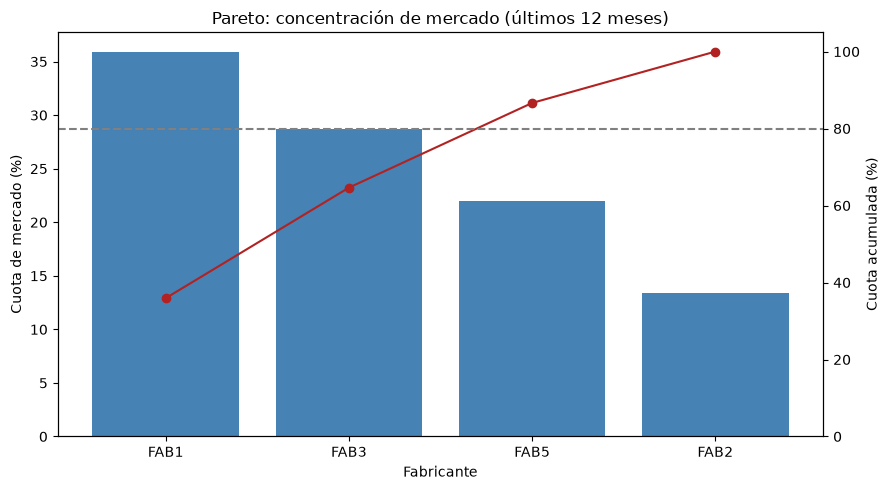

In [15]:
#Se utilizan los df previamente obtenidos para graficar
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(fab_last12['FABRICANTE'], fab_last12['MARKET_SHARE'] * 100, color='steelblue')
ax1.set_ylabel('Cuota de mercado (%)')
ax1.set_xlabel('Fabricante')

ax2 = ax1.twinx()
ax2.plot(fab_last12['FABRICANTE'], fab_last12['SHARE_ACUMULADO'] * 100, color='firebrick', marker='o')
ax2.axhline(80, color='gray', linestyle='--', label='80%')
ax2.set_ylabel('Cuota acumulada (%)')
ax2.set_ylim(0, 105)

plt.title('Pareto: concentración de mercado (últimos 12 meses)')
fig.tight_layout()
plt.show()

In [16]:
# Se obtiene la estadistica descriptiva de los datos
desc_stats = (
    monthly_fab.groupby('FABRICANTE')[['VENTA_VALOR', 'LITROS', 'PRECIO_PROMEDIO_LITRO']]
    .agg(['mean', 'std', 'min', 'max'])
    .round(2)
)
desc_stats

VENTA_VALOR                                            LITROS  \
                   mean         std          min          max        mean   
FABRICANTE                                                                  
FAB1        22467363.21  4165137.82  14909215.92  32581294.08  1106624.09   
FAB2        10459608.26  2853992.29   4905007.17  18292402.85   535650.14   
FAB3        16077260.38  3266014.57  10347451.56  23764535.93   765840.84   
FAB5        12028535.65  6373382.81       235.00  20633808.13   622989.23   
FAB6         1278838.06   454639.48       204.00   1760655.09    82317.39   

                                       PRECIO_PROMEDIO_LITRO               \
                  std     min      max                  mean   std    min   
FABRICANTE                                                                  
FAB1        233279.94  716184  1682580                 20.46  1.56  18.10   
FAB2        174834.46  228120   930132                 20.17  2.90  16.60   
FAB3        164126.33  496008  1080804                 21.11  1.67  18.33   
FAB5        328783.67      12  1058160                 19.31  0.67  17.69   
FAB6         29540.17      12   114336                 15.60  0.91  14.15   

                   
              max  
FABRICANTE         
FAB1        23.66  
FAB2        26.27  
FAB3        24.24  
FAB5        20.38  
FAB6        17.01

### Análisis — Punto 1

En base a los datos obtenidos podemos ver que en cuanto a la composicion de la cuota de mercado por año, el FAB1 es el que lidera el mercado por los 4 años que incluye nuestro dataset. Fab3 se mantiene como el segundo competidor más estale. FAB2 es el tercero aunque mantiene una tendencia a la baja. FAB6 practicamente no tiene participacion en el mercado, lo que lo lleva eventualmente a desaparecer. FAB1, FAB2 y FAb3 fueron los que se mantuvieron presente en todos los años, ahora a partir de 2024 entra el FAB5, el cual entra con una participacion muy baja, pero en 2025 su participacón sube, quitandole participación a FAB1 y FAB2.

En cuanto al desempeño de ventas a lo largo del tiempo, no es de sorprenderse que FAB1, FAB2 y FAB3 tengan el mayor nivel de venta, viendo los resultados del analisis de la composicion de la cuota del mercado. Los precios promedio ponderado de todos los fabricantes muestran una tendencia a subir muy sostenida. Lo mas interesante es como FAB5 se pudo colocar en una muy buena posicion, aun teniendo tan poco tiempo en el mercado.

Los fabricantes que concentran el 80% del mercado en los ultimos 12 meses (los cuales son agosto 2024 a julio 2025) esta conformado principalmente por tres de los cuatro fabricantes activos. FAB1 con 35.9%, FAB3 con 28.7 y FAB5 con 22%, lo que juntos representan el 86.6% acumulado. Esto nos indica que el mercado no esta mayormente dominado por un solo fabricante y muestra una competencia constante por el mercado.

Entonces con todos los datos obtenidos, podemos decir que el fabricante con una mayor estabilidad es FAB1, seguido de FAB3. Con más variabilidad sin dudas es FAB6, el cual nos da la razón con su salida del mercado. Los más volatiles son FAB2 que muestra una tendencia de baja gradual y FAB5 que es por mucho el más volatil, esto debido a que en 2024 practicamente no percibia ventas a que en 2025 tuviera ventas comparables a los lideres del mercado (FAB1 y FAB3).

### 2. Provide initial correlation analysis to understand important relationship within the data. You have to justify how and why you did this correlation analysis. Explain your results

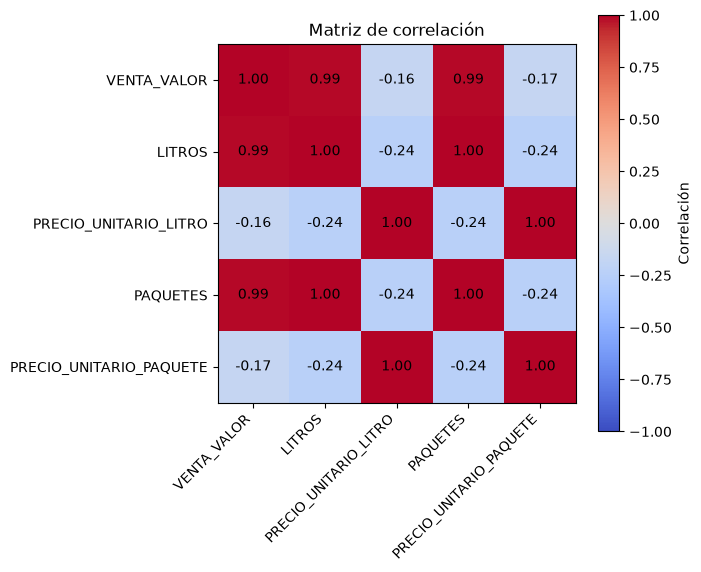

In [17]:
num_cols = ['VENTA_VALOR', 'LITROS', 'PRECIO_UNITARIO_LITRO',
            'PAQUETES', 'PRECIO_UNITARIO_PAQUETE']

corr = df[num_cols].corr()
corr.round(2)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')

ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black')

fig.colorbar(im, label='Correlación')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

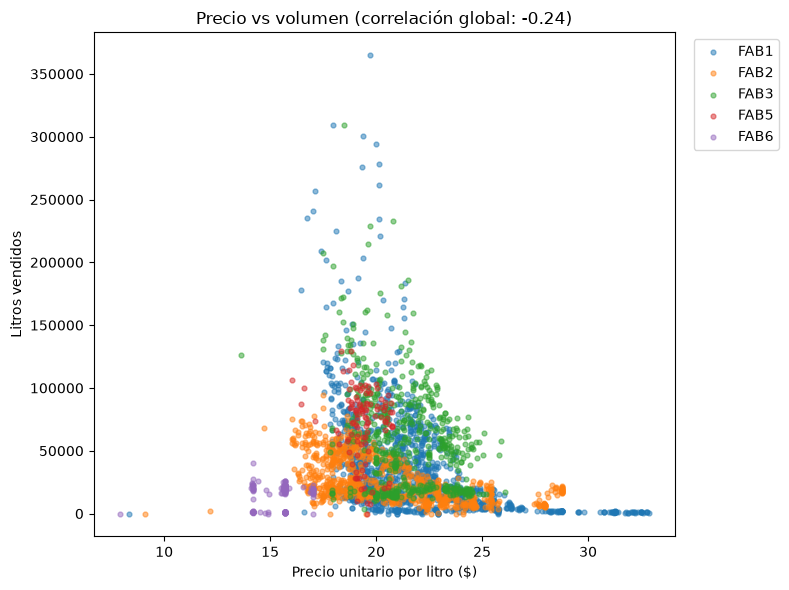

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for fab, g in df.groupby('FABRICANTE'):
    ax.scatter(g['PRECIO_UNITARIO_LITRO'], g['LITROS'], label=fab, alpha=0.5, s=12)

corr_precio_litros = df['PRECIO_UNITARIO_LITRO'].corr(df['LITROS'])
ax.set_xlabel('Precio unitario por litro ($)')
ax.set_ylabel('Litros vendidos')
ax.set_title(f'Precio vs volumen (correlación global: {corr_precio_litros:.2f})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Análisis — Objetivo 2

Para esta correlación usamos las variables tal como vienen, en niveles y no en logaritmos, porque en este punto solo queremos ver las relaciones. Usamos el df ya colapsado de la limpieza, que por cómo se hizo agrupando por FABRICANTE, PRODUCTO y FECHAW (por semana), sin agregar por mes ni por fabricante, para no perder la variación de precio y volumen que hay entre productos y semanas.

En cuanto a las correlaciones que obtuvimos, podemos ver que VENTA_VALOR, LITROS y PAQUETES están relacionados entre sí, al igual que el PRECIO_UNITARIO_LITRO con PRECIO_UNITARIO_PAQUETE. Esto es algo esperado, ya que la venta es precio por cantidad, y el precio por paquete es el precio por litro multiplicado por las unidades del paquete, que es casi constante.

La relación que sí nos interesa analizar es la de PRECIO_UNITARIO_LITRO contra LITROS, la cual dio -0.24. El signo es negativo, lo cual es lo que esperaríamos de la demanda a mayor precio, menor volumen, sin embargo la relación es débil, lo que nos dice que el precio por sí solo no explica bien el volumen cuando juntamos a todos los fabricantes y productos en una sola correlación.

Esto se puede deber a que estamos mezclando productos y fabricantes con precio y volumen muy distintos entre ellos, lo que puede hacer que no se vea reflejado la relación real.

### 3. Design and run regression model(s) to estimate price sensitivity (direct price elasticity) for the top product of your manufacturer (fab#). Identify the top product as the product that sold the most for the last 12 months. For this model, only consider the price change as explanatory variable (do not include other factors such as seasonality or tren).

In [19]:
import numpy as np
import statsmodels.api as sm

df_fab3 = df[df['FABRICANTE'] == 'FAB3'].copy()

# Producto más vendido del FAB3 en los últimos 12 meses que tenemos disponibles
fecha_max_fab3 = df_fab3['FECHAM'].max()
fecha_inicio_fab3 = fecha_max_fab3 - pd.DateOffset(months=11)
fab3_last12 = df_fab3[df_fab3['FECHAM'] >= fecha_inicio_fab3]

ranking_last12 = fab3_last12.groupby('PRODUCTO')['LITROS'].sum().sort_values(ascending=False)
print(f"Ventana últimos 12 meses: {fecha_inicio_fab3.date()} a {fecha_max_fab3.date()}")
print(ranking_last12)

sku_top = ranking_last12.idxmax()
# El modelo se corre con todo el historial disponible de ese producto (más observaciones = mejor ajuste)
df_sku = df_fab3[df_fab3['PRODUCTO'] == sku_top].copy()

monthly_sku = (
    df_sku.groupby('FECHAM', as_index=False)
          .agg(VENTA_VALOR=('VENTA_VALOR', 'sum'), LITROS=('LITROS', 'sum'))
)
# Precio ponderado mensual, igual que en la limpieza inicial
monthly_sku['PRECIO_UNITARIO_LITRO'] = monthly_sku['VENTA_VALOR'] / monthly_sku['LITROS']

monthly_sku['ln_LITROS'] = np.log(monthly_sku['LITROS'])
monthly_sku['ln_PRECIO'] = np.log(monthly_sku['PRECIO_UNITARIO_LITRO'])

X_ll = sm.add_constant(monthly_sku['ln_PRECIO'])
y_ll = monthly_sku['ln_LITROS']

modelo_loglog = sm.OLS(y_ll, X_ll).fit()

print(f"\nSKU top (últimos 12 meses): {sku_top}")
print(f"Observaciones mensuales (historial completo del SKU): {len(monthly_sku)}")
print(modelo_loglog.summary())

Ventana últimos 12 meses: 2024-08-01 a 2025-07-01
PRODUCTO
FAB3_1L  Ent Entera                 4609644
FAB3_1L  Desl Deslactosada          3298020
FAB3_1L  D Li Deslactosada Light     994944
Name: LITROS, dtype: int64

SKU top (últimos 12 meses): FAB3_1L  Ent Entera
Observaciones mensuales (historial completo del SKU): 43
                            OLS Regression Results                            
Dep. Variable:              ln_LITROS   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     19.55
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           7.05e-05
Time:                        15:53:09   Log-Likelihood:                 5.6528
No. Observations:                  43   AIC:                            -7.306
Df Residuals:                      41   BIC:                            -3.783
Df Model:                           1       

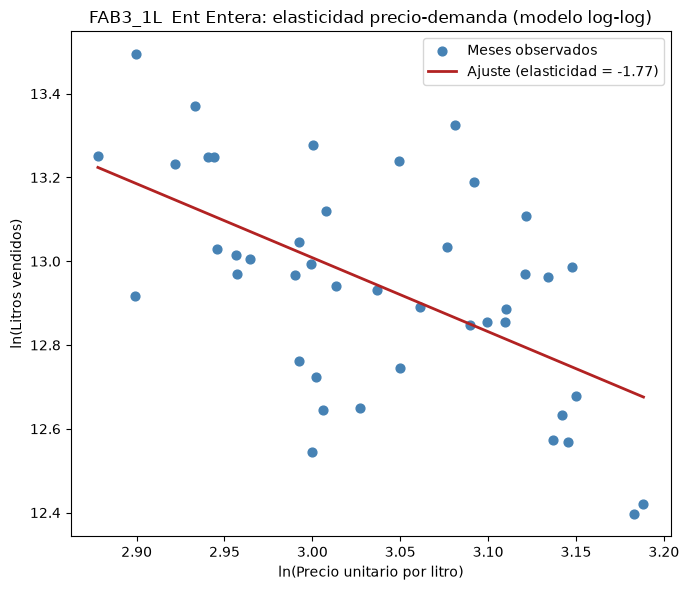

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(monthly_sku['ln_PRECIO'], monthly_sku['ln_LITROS'], color='steelblue', s=40, label='Meses observados')

orden = monthly_sku['ln_PRECIO'].sort_values()
pred = modelo_loglog.predict(sm.add_constant(orden))
ax.plot(orden, pred, color='firebrick', linewidth=2,
        label=f'Ajuste (elasticidad = {modelo_loglog.params["ln_PRECIO"]:.2f})')

ax.set_xlabel('ln(Precio unitario por litro)')
ax.set_ylabel('ln(Litros vendidos)')
ax.set_title(f'{sku_top}: elasticidad precio-demanda (modelo log-log)')
ax.legend()
plt.tight_layout()
plt.show()

### Análisis del modelo — Punto 3

El coeficiente de precio dio -1.77, con un t-stadistic de -4.42 y un p-value bastante menor a 0.05, por lo que es estadisticamente significativo y con una hipótesis nula de que el precio no tiene ningún efecto sobre las ventas, y al tener un p-value tan bajo, rechazamos esa hipótesis nula. 

El intervalo de confianza al 95% va de -2.57 a -0.96, sin tocar el cero, lo que nos indica que el efecto es real. Como las dos variables van en logaritmos, ese número se puede leer directo como la elasticidad, si el precio por litro del producto sube 1%, las ventas en litros bajan 1.77%. Como este número es mayor a 1 en valor absoluto, la demanda del producto FAB3_1L Ent Entera es elástica, o sea que los clientes sí le hacen caso al precio y reaccionan más cuando cambia.

El R² de este modelo es de 0.323, lo cual tiene sentido porque aquí solo estamos dejando que el precio explique el volumen, sin tendencia ni estacionalidad de por medio, entonces es normal que no sea muy alto. Esto quiere decir que el precio por sí solo explica poco más del 32% de la variación en los litros vendidos de este producto. Aun así el coeficiente de precio salió limpio y en la dirección que esperábamos.

Como limitación de este modelo, el Durbin-Watson dio 2.18, bastante cercano a 2, así que no parece haber autocorrelación fuerte en los residuos, lo cual juega a favor de esta especificación. El otro problema es que el precio tiene algo de endogeneidad: como el PRECIO_UNITARIO_LITRO se construye como VENTA_VALOR entre LITROS, en los meses de promoción el precio baja y el volumen sube casi por definición, entonces precio y cantidad se están determinando al mismo tiempo y no es una relación 100% causal en una sola dirección. Además, como aquí no metimos tendencia ni estacionalidad (tal como pide el punto 3), es probable que el coeficiente de precio esté absorbiendo parte del crecimiento natural del volumen y de los patrones estacionales, no solo el efecto puro del precio; eso lo corregimos en el modelo del punto 5.</cell id="10da0848">


### 4. Propose how you could improve your model design to incorporate the following factors: cross-price elasticity with other products, seasonality and growth trend. Here you have to explain your model design, not run the model.

**Cross-price elasticity:** agregaríamos al modelo el precio (en logaritmo) de 1 o 2 productos sustitutos cercanos al producto mas vendido (FAB3_1L Ent Entera). Los los otros productos del FAB3 (FAB3_1L Desl Deslactosada y FAB3_1L D Li Deslactosada Light), porque comparten fabricante, formato y canal, entonces si sube el precio de uno es fácil que el cliente se cambie al otro. Esperaríamos que el efecto de este precio sustituto sea positivo sobre las ventas del producto mas vendido y si sube el precio del sustituto, sube la demanda del producto top porque le quita clientes.

**Seasonality:** agregaríamos una variable categórica por mes (dejando un mes como referencia, para no caer en la trampa de las dummies) para capturar patrones de consumo que se repiten cada año y que no tienen nada que ver con el precio.

**Growth trend:** agregaríamos una variable de tendencia, básicamente un contador que va de 1 hasta el número total de meses observados, para capturar el crecimiento o caída del volumen a lo largo del tiempo, independientemente del precio.

La razón por la que creemos que esto es importante es que en el modelo del punto 3 el precio sube de forma casi constante por inflación a lo largo de los años, entonces el coeficiente de precio que obtuvimos ahí probablemente está absorbiendo parte del efecto de la tendencia y la estacionalidad, y no solo el efecto puro del precio.

Juntando las tres cosas, la ecuación completa de este modelo ampliado quedaría así:

ln_LITROS = const + b1 * ln_PRECIO + b2 * ln_PRECIO_SUSTITUTO + b3 * TENDENCIA + b4*MES_2 + b5*MES_3 + ... + b14*MES_12 + error

(dejando un mes fuera, MES_1 por ejemplo, como referencia para no caer en la trampa de las dummies).

Ahora, meter el precio del sustituto tal cual en niveles tiene un problema práctico: los precios de los distintos productos del FAB3 se mueven casi pegados entre sí porque todos suben con la inflación casi al mismo ritmo (lo comprobamos abajo), entonces meterlos como regresores separados generaría multicolinealidad severa y los coeficientes saldrían poco confiables. Una mejor alternativa sería usar un precio relativo: el precio propio entre el precio de la categoría, en logaritmo, donde el precio de categoría es el precio promedio ponderado de todo el mercado (o del conjunto de sustitutos). Esta variable separa el efecto de sustitución (cuando el producto se encarece más que sus competidores) del efecto de que toda la categoría suba de precio por inflación, que ya quedaría capturado por la tendencia.</cell id="b9ab25f9">


In [21]:
# Chequeo empírico: ¿qué tan correlacionados están los precios de los posibles sustitutos?
# (esto sustenta por qué NO conviene meterlos como regresores sueltos en el modelo ampliado)
monthly_fab3_productos = (
    df_fab3.groupby(['PRODUCTO', 'FECHAM'], as_index=False)
           .agg(VENTA_VALOR=('VENTA_VALOR', 'sum'), LITROS=('LITROS', 'sum'))
)
monthly_fab3_productos['PRECIO'] = monthly_fab3_productos['VENTA_VALOR'] / monthly_fab3_productos['LITROS']

precios_wide = monthly_fab3_productos.pivot(index='FECHAM', columns='PRODUCTO', values='PRECIO')
print("Correlación entre los precios de los productos del FAB3:")
print(precios_wide.corr().round(2))

# Precio de toda la categoría (todos los fabricantes, ponderado por litros)
precio_categoria = (
    df.groupby('FECHAM')
      .apply(lambda g: g['VENTA_VALOR'].sum() / g['LITROS'].sum(), include_groups=False)
      .rename('PRECIO_CATEGORIA')
)
precio_vs_categoria = monthly_sku.merge(precio_categoria, on='FECHAM')
corr_cat = np.corrcoef(
    np.log(precio_vs_categoria['PRECIO_UNITARIO_LITRO']),
    np.log(precio_vs_categoria['PRECIO_CATEGORIA'])
)[0, 1]
print(f"\nCorrelación ln(precio propio) vs ln(precio de toda la categoría): {corr_cat:.2f}")

Correlación entre los precios de los productos del FAB3:
PRODUCTO                          FAB3_1L  D Li Deslactosada Light  \
PRODUCTO                                                             
FAB3_1L  D Li Deslactosada Light                              1.00   
FAB3_1L  Desl Deslactosada                                    0.96   
FAB3_1L  Ent Entera                                           0.96   

PRODUCTO                          FAB3_1L  Desl Deslactosada  \
PRODUCTO                                                       
FAB3_1L  D Li Deslactosada Light                        0.96   
FAB3_1L  Desl Deslactosada                              1.00   
FAB3_1L  Ent Entera                                     0.97   

PRODUCTO                          FAB3_1L  Ent Entera  
PRODUCTO                                               
FAB3_1L  D Li Deslactosada Light                 0.96  
FAB3_1L  Desl Deslactosada                       0.97  
FAB3_1L  Ent Entera                            

Como vemos, los precios de los tres productos del FAB3 están correlacionados entre 0.96 y 0.97 entre sí, y el precio propio también sale correlacionado 0.93 con el precio promedio de toda la categoría. Esto confirma que meter estos precios como regresores separados generaría multicolinealidad severa, y refuerza por qué conviene usar el precio relativo (precio propio entre precio de la categoría) en vez de niveles de precio por separado.

### 5. For your model (of the top product), add variables to include the effects of seasonality and growing volume trend. Interpret the model with your own words.

Run the model, show the regression output and interpret the outputs

                            OLS Regression Results                            
Dep. Variable:              ln_LITROS   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     17.83
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.82e-09
Time:                        15:53:09   Log-Likelihood:                 19.393
No. Observations:                  43   AIC:                            -24.79
Df Residuals:                      36   BIC:                            -12.46
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           18.7035      3.395      5.508   

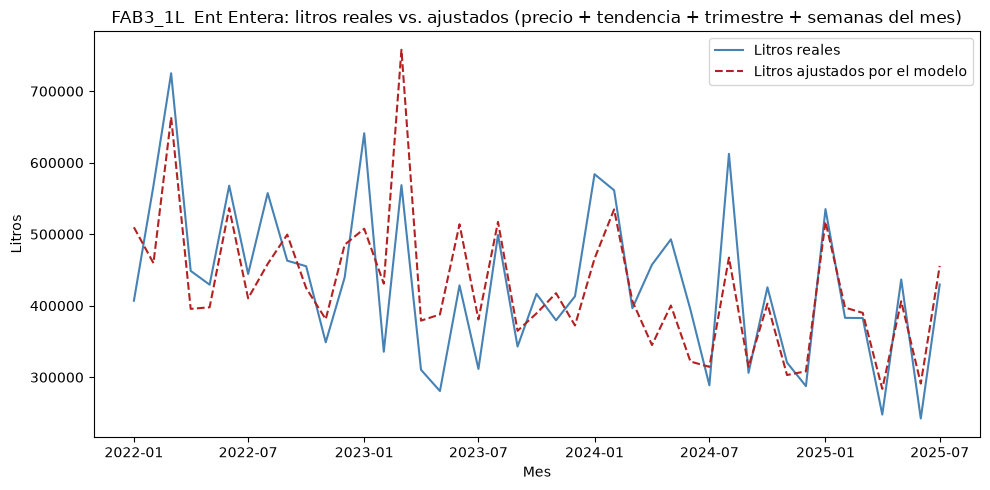


Comparación trimestre (dummies) vs Fourier (misma base: precio + tendencia + N_SEMANAS):
Trimestre - R² ajustado: 0.583 | AIC: -24.79
Fourier   - R² ajustado: 0.576 | AIC: -23.27


In [22]:
# Partimos del mismo monthly_sku del punto 3 (FAB3_1L Ent Entera) y le agregamos
# tendencia (contador de meses), estacionalidad (trimestre) y control por longitud del mes

# Control por longitud del mes: el corte agrupa algunos meses con 4 semanas y otros con 5,
# y eso mueve el volumen del mes de forma mecánica, sin que tenga nada que ver con precio o temporada.
n_semanas = df_sku.groupby('FECHAM')['FECHAW'].nunique().rename('N_SEMANAS')
monthly_sku = monthly_sku.merge(n_semanas, on='FECHAM', how='left')
monthly_sku['ln_N_SEMANAS'] = np.log(monthly_sku['N_SEMANAS'])

monthly_sku = monthly_sku.sort_values('FECHAM').reset_index(drop=True)
monthly_sku['TENDENCIA'] = np.arange(1, len(monthly_sku) + 1)
monthly_sku['TRIMESTRE'] = monthly_sku['FECHAM'].dt.quarter
monthly_sku['MES_NUM'] = monthly_sku['FECHAM'].dt.month

# Usamos trimestre en vez de mes: con solo 43 meses de historia, meter 11 dummies de mes
# deja muy pocos grados de libertad.
# Con trimestre seguimos capturando estacionalidad sin sobreajustar el modelo.
dummies_trimestre = pd.get_dummies(monthly_sku['TRIMESTRE'], prefix='TRIM', drop_first=True, dtype=int)

X_estacional = pd.concat([monthly_sku[['ln_PRECIO', 'TENDENCIA', 'ln_N_SEMANAS']], dummies_trimestre], axis=1)
X_estacional = sm.add_constant(X_estacional)
y_estacional = monthly_sku['ln_LITROS']

# Errores estándar HAC: el Durbin-Watson (ver abajo) muestra algo de autocorrelación en los
# residuos, así que usamos errores robustos a heterocedasticidad y autocorrelación en vez de los clásicos.
modelo_estacional = sm.OLS(y_estacional, X_estacional).fit(cov_type='HAC', cov_kwds={'maxlags': 2})
print(modelo_estacional.summary())
print(f"\nDurbin-Watson: {sm.stats.stattools.durbin_watson(modelo_estacional.resid):.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_sku['FECHAM'], monthly_sku['LITROS'], label='Litros reales', color='steelblue')
ax.plot(monthly_sku['FECHAM'], np.exp(modelo_estacional.fittedvalues),
        label='Litros ajustados por el modelo', color='firebrick', linestyle='--')
ax.set_title(f'{sku_top}: litros reales vs. ajustados (precio + tendencia + trimestre + semanas del mes)')
ax.set_xlabel('Mes')
ax.set_ylabel('Litros')
ax.legend()
plt.tight_layout()
plt.show()

# Ahora probamos una alternativa: términos de Fourier (seno/coseno) en vez de dummies
# trimestrales, para ver si capturan el patrón anual con menos parámetros.
k_armonicos = 2
t_mes = monthly_sku['MES_NUM'].values
X_fourier = pd.DataFrame({
    'ln_PRECIO': monthly_sku['ln_PRECIO'],
    'TENDENCIA': monthly_sku['TENDENCIA'],
    'ln_N_SEMANAS': monthly_sku['ln_N_SEMANAS'],
})
for k in range(1, k_armonicos + 1):
    X_fourier[f'sin_{k}'] = np.sin(2 * np.pi * k * t_mes / 12)
    X_fourier[f'cos_{k}'] = np.cos(2 * np.pi * k * t_mes / 12)
X_fourier = sm.add_constant(X_fourier)

modelo_fourier = sm.OLS(y_estacional, X_fourier).fit(cov_type='HAC', cov_kwds={'maxlags': 2})

print("\nComparación trimestre (dummies) vs Fourier (misma base: precio + tendencia + N_SEMANAS):")
print(f"Trimestre - R² ajustado: {modelo_estacional.rsquared_adj:.3f} | AIC: {modelo_estacional.aic:.2f}")
print(f"Fourier   - R² ajustado: {modelo_fourier.rsquared_adj:.3f} | AIC: {modelo_fourier.aic:.2f}")

### Análisis del modelo — Punto 5

Al modelo del punto 3 le agregamos tendencia (un contador de 1 a 43), trimestre (dummies, dejando el primer trimestre como referencia) y el número de semanas que tiene cada mes, en logaritmo (N_SEMANAS), porque el corte agrupa algunos meses con 4 semanas y otros con 5, y eso mueve el volumen del mes de forma mecánica sin que tenga nada que ver con precio o temporada. También usamos errores estándar HAC (robustos a heterocedasticidad y autocorrelación), porque el Durbin-Watson de este modelo bajó a 1.44 frente al 2.18 del modelo simple, señal de que sí quedaba algo de autocorrelación en los residuos.

El coeficiente de precio dio -2.46, con un error estándar HAC de 1.12, un t-statistic de -2.19 y un p-value de 0.028, así que sigue siendo significativo al 5%. Su intervalo de confianza al 95% va de -4.66 a -0.26, sin tocar el cero.

N_SEMANAS salió con coeficiente 1.13, con un t-statistic de 6.17 y un p-value menor a 0.001, muy significativo: un mes con 5 semanas en vez de 4 (25% más semanas) predice cerca de 28% más litros vendidos ese mes, en línea con el ~25% que ya se podía esperar para este factor. Antes de meter esta variable, ese efecto puramente mecánico se estaba colando en el error del modelo.

La tendencia dio un coeficiente de 0.0066, pero con un p-value de 0.317 ya no es significativa ni al 10%: buena parte de lo que en un primer intento (sin N_SEMANAS) parecía "crecimiento del volumen mes a mes" en realidad era la variación en el número de semanas de cada mes, no una tendencia genuina de la demanda.

De las dummies de trimestre, solo TRIM_4 salió significativa al 5% (coeficiente -0.127, p-value de 0.015); TRIM_2 y TRIM_3 no lo son. El R² subió a 0.643 (R² ajustado 0.583), muy por encima del 0.323 del modelo simple.

Por último, probamos una versión alternativa cambiando las dummies trimestrales por términos de Fourier (2 armónicos seno/coseno), dejando igual el precio, la tendencia y N_SEMANAS. El ajuste salió prácticamente igual (R² ajustado 0.576 contra 0.583, AIC -23.27 contra -24.79), así que nos quedamos con las dummies trimestrales porque salieron un poco mejor en esta base y son más fáciles de interpretar.</cell id="6db6b574">


### Did the estimates of direct price elasticity change compared with the previous model? What happened with the statistical significance of the price elasticity? Why do you think the estimates change, and which estimate is the best? Explain clearly with your own words.

Sí cambió, aunque no fue tan simple como en la comparación anterior. Con precio + tendencia + trimestre (sin controlar la duración del mes) nos había dado un coeficiente de -3.40; al meter N_SEMANAS ese coeficiente bajó en magnitud a -2.46, porque parte de lo que ese primer modelo le achacaba al precio en realidad era el efecto mecánico de que unos meses tienen 4 semanas y otros 5.

Comparando el modelo final (precio + tendencia + trimestre + N_SEMANAS) contra el modelo simple del punto 3: el coeficiente de precio pasó de -1.77 a -2.46. Se mantiene significativo en los dos, pero el p-value pasó de mucho menor a 0.05 a 0.028, y el error estándar del precio subió de 0.40 a 1.12 (ya con la corrección HAC), por lo que el t-statistic bajó de -4.42 a -2.19. El intervalo de confianza al 95% también se hizo más ancho, de -4.66 a -0.26.

Esto pasa porque el precio y la tendencia están muy correlacionados entre sí (correlación de 0.92), ya que el precio sube de forma casi constante con el paso del tiempo por la inflación. Al meter las dos variables juntas en el modelo, se vuelve más difícil separar qué parte del cambio en litros es por el precio y cuál es por el simple paso del tiempo, y eso es lo que infla el error estándar. En cambio, N_SEMANAS no está correlacionada ni con el precio ni con la tendencia, así que no mete ese mismo problema de multicolinealidad: simplemente no estaba en el modelo antes, y su ausencia se colaba como ruido en el error.

También encontramos que el Durbin-Watson de este modelo bajó a 1.44 (contra 2.18 del modelo simple), señal de que sí queda algo de autocorrelación en los residuos, y por eso reportamos los errores estándar con la corrección HAC en vez de los clásicos.

Creemos que el modelo del punto 3 tenía un sesgo, porque al no incluir la tendencia, el coeficiente de precio estaba absorbiendo parte del efecto del crecimiento natural del volumen a través del tiempo. Y el modelo final (con tendencia, trimestre y N_SEMANAS) es el mejor de los tres que probamos: corrige ese sesgo y además aísla el efecto mecánico de la duración del mes que nuestro primer intento de modelo ampliado todavía no controlaba. Aun así, hay que ser honestos con que el intervalo de confianza de la elasticidad es amplio (-4.66 a -0.26): tenemos claro que la demanda es elástica y que el efecto del precio es negativo, pero la magnitud exacta sigue siendo imprecisa.



### 6. Propose how you could forecast price and sales of the top product for the next 24 months. Which types of models you can use to do this. You have to do your own research. Consider not only regression models, but any type of machine learning/ AI models.

Para los modelos de precio y ventas, en vez de una regresión clásica propongo usar Random Forest o Gradient Boosting, modelos de machine learning basados en árboles. La ventaja frente a la regresión es que pueden capturar relaciones no lineales entre litros, precio, mes y tendencia, y se les puede agregar fácilmente más variables sin preocuparse tanto por la multicolinealidad que sí nos afectó en el punto 5. Random Forest es más simple de entrenar y menos propenso a sobreajustar con pocos datos, mientras que Gradient Boosting suele ser más preciso pero necesita más cuidado para no sobreajustar con una muestra tan chica.

No creo que modelos de deep learning como DeepAR de Amazon sean convenientes para este caso, ya que normalmente necesitan muchos más datos de los que tenemos.

Aquí es importante aclarar algo, sin importar qué tan sofisticado sea el modelo que elijamos, con solo 43 meses de historia y pronosticando 24 meses hacia adelante, practicamente ningún modelo va a poder predecir con mucha precisión, porque simplemente no hay suficiente información para que aprenda bien los patrones de largo plazo. Esto no es un problema de qué modelo se use, sino de la cantidad de datos disponibles, así que cualquier pronóstico que hagamos debería presentarse con un rango de confianza y no como un número exacto, e idealmente recalcularse conforme se vayan teniendo más meses de datos reales.